### Figure S5

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
import zipfile
import warnings
import fed3bandit as f3b
import copy
from pandas.api.types import CategoricalDtype
from scipy.stats import ttest_rel, ttest_ind
from osfclient import OSF

warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.size': 32, 
    'figure.autolayout': True, 
    'lines.linewidth': 2, 
    'axes.spines.top': False, 
    'axes.spines.right': False
    })

cat_size_order = CategoricalDtype(['Sal', 'MK801_2ug', 'MK801_4ug'], ordered=True)

Fetching data from OSF and extracting it


In [5]:
# Create output directory
output_dir = "osf_downloads"
os.makedirs(output_dir, exist_ok=True)

# Connect to OSF
osf = OSF()
project = osf.project('stk2r')
storage = project.storage('osfstorage')

# Set up folder name with data
target_filename = 'Figure_S5_data.zip'

# Download zip file with data
for file in storage.files:
    if file.name == target_filename:
        output_path = os.path.join(output_dir, file.name)
        with open(output_path, 'wb') as f:
            file.write_to(f)
        print(f"Downloaded: {file.name} to {output_path}")
        break
else:
    print(f"File '{target_filename}' not found in OSF storage.")

#Set up 
zip_path = 'osf_downloads/Figure_S5_data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted all files to {output_dir}")

100%|██████████| 561k/561k [00:00<00:00, 1.96Mbytes/s]


Downloaded: Figure_S5_data.zip to osf_downloads\Figure_S5_data.zip
Extracted all files to osf_downloads


Formatting the data for analysis and adding injection times

In [ ]:
fileloc = os.path.join(os.getcwd(), "osf_downloads", "Figure_S5_data")

saline_2ug_data = {
    "saline_1": {
        "C116F2": pd.read_csv(fileloc + "\\saline_2ug_C116F2_icv_060523.csv"),
        "C116F4": pd.read_csv(fileloc + "\\saline_2ug_C116F4_icv_060523.csv")
        },
    "saline_2": {
        "C75M1": pd.read_csv(fileloc + "\\saline_2ug_C75M1_icv_060623.csv"),
        "C75M3": pd.read_csv(fileloc + "\\saline_2ug_C75M3_icv_060623.csv"),       
        },
    "saline_3": {
        "C116F1": pd.read_csv(fileloc + "\\saline_2ug_C116F1_icv_061323.csv"),
        },
    "saline_4": {
        "C48M3": pd.read_csv(fileloc + "\\saline_2ug_C48M3_icv_062023.csv"),
        "C50F5": pd.read_csv(fileloc + "\\saline_2ug_C50F5_icv_062023.csv")
        },
    "saline_5": {
        "C50F1": pd.read_csv(fileloc + "\\saline_2ug_C50F1_icv_063023.csv")
        },
    "saline_6": {
        "C129F1": pd.read_csv(fileloc + "\\saline_2ug_C129F1_icv_091223.csv"),
        "C84M2": pd.read_csv(fileloc + "\\saline_2ug_C84M2_icv_091223.csv")
        },
    "saline_7": {
        "C86F1": pd.read_csv(fileloc + "\\saline_2ug_C86F1_icv_091823.csv"),
        "C86F2": pd.read_csv(fileloc + "\\saline_2ug_C86F2_icv_091823.csv")
        }
    }

saline_2ug_injectiontimes = {
    "saline_1": datetime.datetime(2023, 6, 5, 19),
    "saline_2": datetime.datetime(2023, 6, 6, 18, 30),
    "saline_3": datetime.datetime(2023, 6, 13, 17, 45),
    "saline_4": datetime.datetime(2023, 6, 20, 18, 5),
    "saline_5": datetime.datetime(2023, 6, 30, 16, 45),
    "saline_6": datetime.datetime(2023, 9, 12, 19, 10),
    "saline_7": datetime.datetime(2023, 9, 18, 18, 45)
    }
    
#MK801 2ug
mk801_2ug_data = {
    "mk801_1": {
        "C48M3": pd.read_csv(fileloc + "\\mk801_2ug_C48M3_icv_060623.csv")
        },
    "mk801_2": {
        "C116F2": pd.read_csv(fileloc + "\\mk801_2ug_C116F2_icv_061323.csv"),
        "C116F4": pd.read_csv(fileloc + "\\mk801_2ug_C116F4_icv_061323.csv")
        },
    "mk801_3": {
        "C75M1": pd.read_csv(fileloc + "\\mk801_2ug_C75M1_icv_062023.csv"),
        "C116F1": pd.read_csv(fileloc + "\\mk801_2ug_C116F1_icv_062023.csv")
        },
    "mk801_4": {
        "C75M3": pd.read_csv(fileloc + "\\mk801_2ug_C75M3_icv_062623.csv"),
        "C50F1": pd.read_csv(fileloc + "\\mk801_2ug_C50F1_icv_062623.csv"),
        "C50F5": pd.read_csv(fileloc + "\\mk801_2ug_C75M3_icv_062623.csv")
        },
    "mk801_5": {
        "C86F1": pd.read_csv(fileloc + "\\mk801_2ug_C86F1_icv_091223.csv"),
        "C86F2": pd.read_csv(fileloc + "\\mk801_2ug_C86F2_icv_091223.csv")
        },
    "mk801_6": {
        "C129F1": pd.read_csv(fileloc + "\\mk801_2ug_C129F1_icv_091823.csv"),
        "C84M2": pd.read_csv(fileloc + "\\mk801_2ug_C84M2_icv_091823.csv")
        }
    }

mk801_2ug_injectiontimes = {
    "mk801_1": datetime.datetime(2023, 6, 6, 18, 30),
    "mk801_2": datetime.datetime(2023, 6, 13, 16, 22),
    "mk801_3": datetime.datetime(2023, 6, 20, 18, 45),
    "mk801_4": datetime.datetime(2023, 6, 26, 18, 45),
    "mk801_5": datetime.datetime(2023, 9, 12, 19, 10),
    "mk801_6": datetime.datetime(2023, 9, 18, 18, 45)
    }

#
saline_4ug_data = {
    "saline_1": {
        "C116F3": pd.read_csv(fileloc + "\\saline_4ug_C116F3_icv_053023.csv"),
        },
    "saline_2": {
        "C48M3": pd.read_csv(fileloc + "\\saline_4ug_C48M3_icv_060123.csv"),
        },
    "saline_3": {
        "C50F5": pd.read_csv(fileloc + "\\saline_4ug_C50F5_icv_060523.csv"),
        "C116F1": pd.read_csv(fileloc + "\\saline_4ug_C116F1_icv_060523.csv"),
        },
    "saline_4": {
        "C86F1": pd.read_csv(fileloc + "\\saline_4ug_C86F1_icv_092523.csv"),
        "C86F2": pd.read_csv(fileloc + "\\saline_4ug_C86F2_icv_092523.csv")
        },
    "saline_5": {
        "C129F1": pd.read_csv(fileloc + "\\saline_4ug_C129F1_icv_100423.csv"),
        "C84M2": pd.read_csv(fileloc + "\\saline_4ug_C84M2_icv_100423.csv")
        },
    "saline_6": {
        "FCK4M1": pd.read_csv(fileloc + r"\saline_4ug_FCK4M1_111224_01.CSV"),
        "FCK4M3": pd.read_csv(fileloc + r"\saline_4ug_FCK4M3_111224_00.CSV"),
        },
    "saline_7": {
        "FCK3F1": pd.read_csv(fileloc + r"\saline_4ug_FCK3F1_111324_00.CSV")
        },
    "saline_8": {
        "FCK4M2": pd.read_csv(fileloc + r"\saline_4ug_FCK4M2_111924_02.CSV"),
        "FCK3F3": pd.read_csv(fileloc + r"\saline_4ug_FCK3F3_111924_00.CSV")
        },
    "saline_9": {
        "FCK5M3": pd.read_csv(fileloc + r"\saline_4ug_FCK5M3_010925_01.CSV"),
        "FCK5M4": pd.read_csv(fileloc + r"\saline_4ug_FCK5M4_010925_01.CSV")
        },
    }

saline_4ug_injectiontimes = {
    "saline_1": datetime.datetime(2023, 5, 30, 18, 45),
    "saline_2": datetime.datetime(2023, 6, 1, 18, 30),
    "saline_3": datetime.datetime(2023, 6, 5, 19, 15),
    "saline_4": datetime.datetime(2023, 9, 25, 19, 40),
    "saline_5": datetime.datetime(2023, 10, 4, 19, 10),
    "saline_6": datetime.datetime(2024, 11, 12, 19, 45),
    "saline_7": datetime.datetime(2024, 11, 13, 20, 55),
    "saline_8": datetime.datetime(2024, 11, 19, 18, 43), 
    "saline_9": datetime.datetime(2025, 1, 9, 17, 12) 
    }

#MK801 Data    
mk801_4ug_data = {
    "mk801_1": {
        "C50F5": pd.read_csv(fileloc + "\\mk801_4ug_C50F5_icv_053023.csv"),
        "C116F2": pd.read_csv(fileloc + "\\mk801_4ug_C116F2_icv_053023.csv"),
        "C116F4": pd.read_csv(fileloc + "\\mk801_4ug_C116F4_icv_053023.csv")
        },
    "mk801_2": {
        "C75M1": pd.read_csv(fileloc + "\\mk801_4ug_C75M1_icv_060123.csv"),
        "C75M2": pd.read_csv(fileloc + "\\mk801_4ug_C75M2_icv_060123.csv"),
        "C75M3": pd.read_csv(fileloc + "\\mk801_4ug_C75M3_icv_060123.csv"),
        },
    "mk801_3": {
        "C129F1": pd.read_csv(fileloc + "\\mk801_4ug_C129F1_icv_092523.csv"),
        "C84M2": pd.read_csv(fileloc + "\\mk801_4ug_C84M2_icv_092523.csv")
        },
    "mk801_4": {
        "C86F1": pd.read_csv(fileloc + "\\mk801_4ug_C86F1_icv_100423.csv"),
        "C86F2": pd.read_csv(fileloc + "\\mk801_4ug_C86F2_icv_100423.csv")
        },
    "mk801_5": {
        "FCK4M1": pd.read_csv(fileloc + r"\mk801_4ug_FCK4M1_112524_00.CSV"),
        "FCK4M3": pd.read_csv(fileloc + r"\mk801_4ug_FCK4M3_112524_01.CSV"),
        },
    "mk801_6": {
        "FCK3F1": pd.read_csv(fileloc + r"\mk801_4ug_FCK3F1_111824_00.CSV")
        },
    "mk801_7": {
        "FCK4M2": pd.read_csv(fileloc + r"\mk801_4ug_FCK4M2_112524_00.CSV"),
        "FCK3F3": pd.read_csv(fileloc + r"\mk801_4ug_FCK3F3_112524_01.CSV")
        },
    "mk801_8": {
        "FCK5M3": pd.read_csv(fileloc + r"\mk801_4ug_FCK5M3_011625_00.csv"),
        "FCK5M4": pd.read_csv(fileloc + r"\mk801_4ug_FCK5M4_011625_00.csv")
        },
    }

mk801_4ug_injectiontimes = {
    "mk801_1": datetime.datetime(2023, 5, 30, 18, 45),
    "mk801_2": datetime.datetime(2023, 6, 1, 18, 30),
    "mk801_3": datetime.datetime(2023, 9, 25, 19, 40),
    "mk801_4": datetime.datetime(2023, 10, 4, 19, 10),
    "mk801_5": datetime.datetime(2024, 11, 25, 20, 20),
    "mk801_6": datetime.datetime(2024, 11, 18, 20, 37),
    "mk801_7": datetime.datetime(2024, 11, 25, 20, 20),
    "mk801_8": datetime.datetime(2025, 1, 16, 17, 59)
    }

print("All data was reformatted succesfully")

All data was reformatted succesfully


Data pre-processing

In [12]:
"""
First, we filter out events to only include valid pokes ("Left" and "Right" events").
Then, we make sure that the first column is of datetime type
"""

#Saline injection on the 2ug group
p_saline_2ug_data = {}
for session in saline_2ug_data:
    c_session = saline_2ug_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_saline_2ug_data[session] = p_session

#MK801 injection on the 2ug group
p_mk801_2ug_data = {}
for session in mk801_2ug_data:
    c_session = mk801_2ug_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_mk801_2ug_data[session] = p_session

#Saline injection on the 4ug group
p_saline_4ug_data = {}
for session in saline_4ug_data:
    c_session = saline_4ug_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_saline_4ug_data[session] = p_session
    
#C84M2 FED was off by 1 hour on 10/04. Here we fix it
p_saline_4ug_data["saline_5"]["C84M2"].iloc[:,0] = p_saline_4ug_data["saline_5"]["C84M2"].iloc[:,0] - datetime.timedelta(hours=1)

#MK801 injection on the 4ug group
p_mk801_4ug_data = {}
for session in mk801_4ug_data:
    c_session = mk801_4ug_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_mk801_4ug_data[session] = p_session

In [14]:
"""Slice data to only eight hours after intra-striatal infusion (or injection)."""

post_hours = 8

# The saline groups
saline_2ug_slices = {}
for session in p_saline_2ug_data:
    c_session = p_saline_2ug_data[session]
    c_injection = saline_2ug_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    saline_2ug_slices[session] = s_session
       
# The MK801 groups                               
mk801_2ug_slices = {}
for session in p_mk801_2ug_data:
    c_session = p_mk801_2ug_data[session]
    c_injection = mk801_2ug_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    mk801_2ug_slices[session] = s_session


# The saline groups
saline_4ug_slices = {}
for session in p_saline_4ug_data:
    c_session = p_saline_4ug_data[session]
    c_injection = saline_4ug_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    saline_4ug_slices[session] = s_session
       
# The MK801 groups                               
mk801_4ug_slices = {}
for session in p_mk801_4ug_data:
    c_session = p_mk801_4ug_data[session]
    c_injection = mk801_4ug_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    mk801_4ug_slices[session] = s_session

print("All files have been successfully filtered and sliced")

All files have been successfully filtered and sliced


Calculation of Block change peri-event histogram

In [ ]:
m_sal_2ug_pehs = {}
for session in saline_2ug_slices:
    c_session = saline_2ug_slices[session]
    c_pehs = {mouse: f3b.reversal_peh(c_session[mouse], (-10,11)).mean(axis=0) for mouse in c_session}
    c_pehs_df = pd.DataFrame(c_pehs)
    c_pehs_df = c_pehs_df.assign(Trial=np.arange(-10,11), Treatment="Sal")
    m_c_pehs = pd.melt(c_pehs_df, id_vars=["Trial", "Treatment"])
    m_sal_2ug_pehs[session] = m_c_pehs

m_sal_2ug_pehs = pd.concat(m_sal_2ug_pehs.values())

m_mk801_2ug_pehs = {}
for session in mk801_2ug_slices:
    c_session = mk801_2ug_slices[session]
    c_pehs = {mouse: f3b.reversal_peh(c_session[mouse], (-10,11)).mean(axis=0) for mouse in c_session}
    c_pehs_df = pd.DataFrame(c_pehs)
    c_pehs_df = c_pehs_df.assign(Trial=np.arange(-10,11), Treatment="MK801_2ug")
    m_c_pehs = pd.melt(c_pehs_df, id_vars=["Trial", "Treatment"])
    m_mk801_2ug_pehs[session] = m_c_pehs

m_mk801_2ug_pehs = pd.concat(m_mk801_2ug_pehs.values())
m_all_2ug_pehs = pd.concat([m_sal_2ug_pehs, m_mk801_2ug_pehs])



#
m_sal_4ug_pehs = {}
for session in saline_4ug_slices:
    c_session = saline_4ug_slices[session]
    c_pehs = {mouse: f3b.reversal_peh(c_session[mouse], (-10,11)).mean(axis=0) for mouse in c_session}
    c_pehs_df = pd.DataFrame(c_pehs)
    c_pehs_df = c_pehs_df.assign(Trial=np.arange(-10,11), Treatment="Sal")
    m_c_pehs = pd.melt(c_pehs_df, id_vars=["Trial", "Treatment"])
    m_sal_4ug_pehs[session] = m_c_pehs

m_sal_4ug_pehs = pd.concat(m_sal_4ug_pehs.values())

#
m_mk801_4ug_pehs = {}
for session in mk801_4ug_slices:
    c_session = mk801_4ug_slices[session]
    c_pehs = {mouse: f3b.reversal_peh(c_session[mouse], (-10,11)).mean(axis=0) for mouse in c_session}
    c_pehs_df = pd.DataFrame(c_pehs)
    c_pehs_df = c_pehs_df.assign(Trial=np.arange(-10,11), Treatment="MK801_4ug")
    m_c_pehs = pd.melt(c_pehs_df, id_vars=["Trial", "Treatment"])
    m_mk801_4ug_pehs[session] = m_c_pehs

m_mk801_4ug_pehs = pd.concat(m_mk801_4ug_pehs.values())
m_all_4ug_pehs = pd.concat([m_sal_4ug_pehs, m_mk801_4ug_pehs])

#
m_all_pehs = pd.concat([m_sal_2ug_pehs, m_sal_4ug_pehs, m_mk801_2ug_pehs, m_mk801_4ug_pehs])




Plot of PEH. Figure S5B, left.

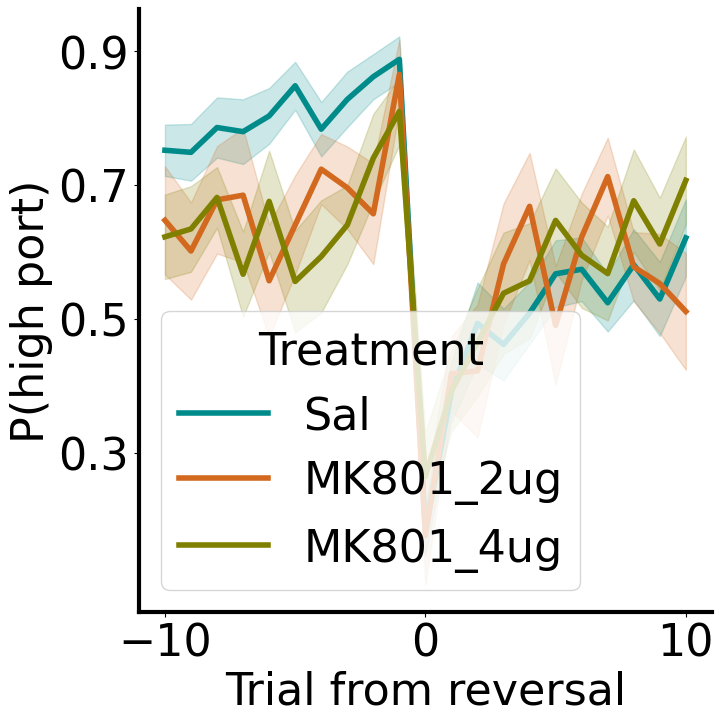

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.lineplot(x="Trial", y="value", hue="Treatment", data=m_all_pehs, linewidth=4, palette=["darkcyan", "chocolate", "olive"], errorbar="se")
ax.set_ylabel("P(high port)")
ax.set_xlabel("Trial from reversal")
ax.set_yticks(np.arange(0.3, 1, 0.2))
sns.despine()
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

#Accuracy of trials prior to reversal
all_pre_pehs = m_all_pehs[m_all_pehs["Trial"] < 0]
mean_pre_pehs = all_pre_pehs.groupby(["Treatment", "variable"]).mean().reset_index()
mean_pre_pehs["Treatment"] = mean_pre_pehs["Treatment"].astype(cat_size_order)
mean_pre_pehs = mean_pre_pehs.sort_values(by="Treatment")

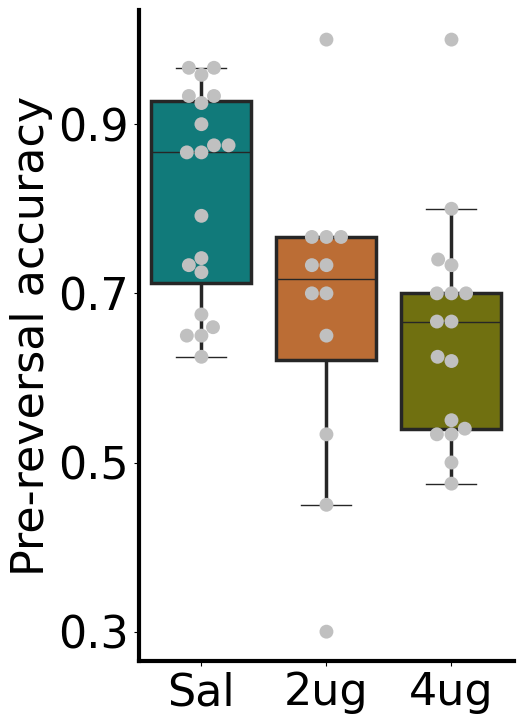

In [ ]:
"""Finding the average accuracy prior to the block change."""

fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(x="Treatment", y="value", data=mean_pre_pehs, palette=["darkcyan", 
            "chocolate", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="Treatment", y="value", data=mean_pre_pehs, palette=["silver", "silver", "silver"], s=10)
ax.set_ylabel("Pre-reversal accuracy")
ax.set_xlabel("")
ax.set_yticks(np.arange(0.3, 1, 0.2))
ax.set_xticklabels(["Sal", "2ug", "4ug"])
sns.despine()
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

Calculation of pokes, pellets, and win-stay metric.
For documentation and source code of FED3Bandit package, which is used to calculate metrics, please see:

FED3Bandit package documentation: https://fed3bandit.readthedocs.io/en/latest/analysis/fed3live_api.html

FED3Bandit package source code:  https://github.com/AlexLM96/fed3bandit/blob/main/fed3bandit/fed3bandit/fed3bandit.py

In [64]:
# Win-stay for the 2ug saline group
saline_2ug_ws = {}
for session in saline_2ug_slices:
    c_session = saline_2ug_slices[session]
    c_session_ws = {mouse: [f3b.win_stay(c_session[mouse])] for mouse in c_session}
    saline_2ug_ws = saline_2ug_ws | c_session_ws
    
saline_2ug_ws = pd.DataFrame(saline_2ug_ws).T
saline_2ug_ws["Treatment"] = "Sal"
saline_2ug_ws = saline_2ug_ws.reset_index()
saline_2ug_ws.columns = ["Mouse", "win-stay", "Treatment"]

# Win-stay for the 2ug MK801 group
mk801_2ug_ws = {}
for session in mk801_2ug_slices:
    c_session = mk801_2ug_slices[session]
    c_session_ws = {mouse: [f3b.win_stay(c_session[mouse])] for mouse in c_session}
    mk801_2ug_ws = mk801_2ug_ws | c_session_ws
    
mk801_2ug_ws = pd.DataFrame(mk801_2ug_ws).T.reset_index()
mk801_2ug_ws["Treatment"] = "MK801_2ug"
mk801_2ug_ws.columns = ["Mouse", "win-stay", "Treatment"]

# Win-stay for the 4ug saline group
saline_4ug_ws = {}
for session in saline_4ug_slices:
    c_session = saline_4ug_slices[session]
    c_session_ws = {mouse: [f3b.win_stay(c_session[mouse])] for mouse in c_session}
    saline_4ug_ws = saline_4ug_ws | c_session_ws
    
saline_4ug_ws = pd.DataFrame(saline_4ug_ws).T
saline_4ug_ws["Treatment"] = "Sal"
saline_4ug_ws = saline_4ug_ws.reset_index()
saline_4ug_ws.columns = ["Mouse", "win-stay", "Treatment"]


# Win-stay for the 4ug MK801 group
mk801_4ug_ws = {}
for session in mk801_4ug_slices:
    c_session = mk801_4ug_slices[session]
    c_session_ws = {mouse: [f3b.win_stay(c_session[mouse])] for mouse in c_session}
    mk801_4ug_ws = mk801_4ug_ws | c_session_ws
    
mk801_4ug_ws = pd.DataFrame(mk801_4ug_ws).T
mk801_4ug_ws["Treatment"] = "MK801_4ug"
mk801_4ug_ws = mk801_4ug_ws.reset_index()
mk801_4ug_ws.columns = ["Mouse", "win-stay", "Treatment"]


# We pool all the numbers
all_ws = pd.concat([saline_2ug_ws, saline_4ug_ws, mk801_2ug_ws, mk801_4ug_ws], axis=0)
all_ws["Treatment"] = all_ws["Treatment"].astype(cat_size_order)
all_ws = all_ws.groupby(["Treatment", "Mouse"]).mean().reset_index()
all_ws = all_ws.sort_values(by="Treatment")


Plot of win-stay. Figure S5C

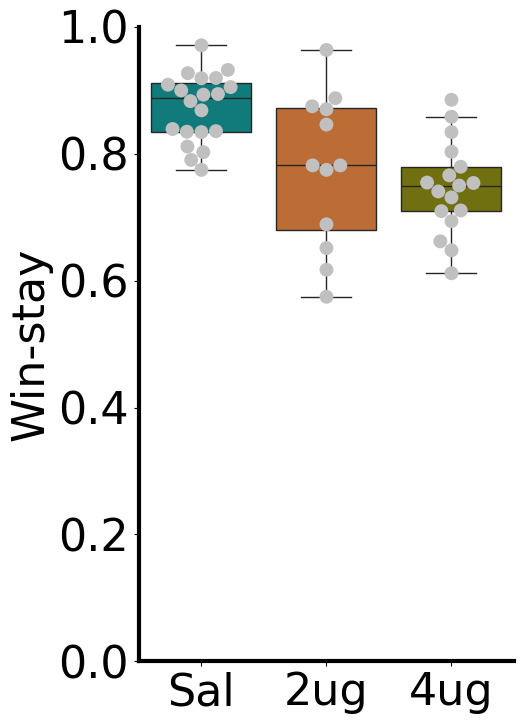

In [65]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(x="Treatment", y="win-stay", data=all_ws, palette=["darkcyan", "chocolate", "olive"])
sns.swarmplot(x="Treatment", y="win-stay", data=all_ws, palette=["silver", "silver", "silver"], s=10)
ax.set_ylabel("Win-stay")
ax.set_xlabel("")
ax.set_xticklabels(["Sal", "2ug", "4ug"])
ax.set_ylim(0,1)
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
sns.despine()

Fitting the logistic regression to test influence of past rewarded trials on behavior.

In [73]:
saline_2ug_pcoeffs = {}
for session in saline_2ug_slices:
    c_session = saline_2ug_slices[session]
    c_session_sidep = {mouse: f3b.side_prewards(c_session[mouse]) for mouse in c_session}
    c_session_preX = {mouse: f3b.create_X(c_session[mouse], c_session_sidep[mouse], 5)
                      for mouse in c_session_sidep}
    c_session_pcoeffs = {mouse: f3b.logit_regr(c_session_preX[mouse]).params for mouse in c_session_preX}
    saline_2ug_pcoeffs = saline_2ug_pcoeffs | c_session_pcoeffs
    
saline_2ug_pcoeffs = pd.DataFrame(saline_2ug_pcoeffs)
saline_2ug_pcoeffs = saline_2ug_pcoeffs.assign(Treatment="Sal", Trial=np.flip(np.arange(-5, 0, 1)))
m_saline_2ug_pcoeffs = pd.melt(saline_2ug_pcoeffs, id_vars=["Treatment", "Trial"])

#Saline from 4ug
saline_4ug_pcoeffs = {}
for session in saline_4ug_slices:
    c_session = saline_4ug_slices[session]
    c_session_sidep = {mouse: f3b.side_prewards(c_session[mouse]) for mouse in c_session}
    c_session_preX = {mouse: f3b.create_X(c_session[mouse], c_session_sidep[mouse], 5)
                      for mouse in c_session_sidep}
    c_session_pcoeffs = {mouse: f3b.logit_regr(c_session_preX[mouse]).params for mouse in c_session_preX}
    saline_4ug_pcoeffs = saline_4ug_pcoeffs | c_session_pcoeffs
    
saline_4ug_pcoeffs = pd.DataFrame(saline_4ug_pcoeffs)
saline_4ug_pcoeffs = saline_4ug_pcoeffs.assign(Treatment="Sal", Trial=np.flip(np.arange(-5, 0, 1)))
m_saline_4ug_pcoeffs = pd.melt(saline_4ug_pcoeffs, id_vars=["Treatment", "Trial"])

# Count of ws after mk801 injections
mk801_2ug_pcoeffs = {}
for session in mk801_2ug_slices:
    print(session)
    c_session = mk801_2ug_slices[session]
    c_session_sidep = {mouse: f3b.side_prewards(c_session[mouse]) for mouse in c_session}
    c_session_preX = {mouse: f3b.create_X(c_session[mouse], c_session_sidep[mouse], 5)
                      for mouse in c_session_sidep}
    c_session_pcoeffs = {mouse: f3b.logit_regr(c_session_preX[mouse]).params for mouse in c_session_preX}
    mk801_2ug_pcoeffs = mk801_2ug_pcoeffs | c_session_pcoeffs
    
mk801_2ug_pcoeffs = pd.DataFrame(mk801_2ug_pcoeffs)
mk801_2ug_pcoeffs = mk801_2ug_pcoeffs.assign(Treatment="MK801_2ug", Trial=np.flip(np.arange(-5, 0, 1)))
m_mk801_2ug_pcoeffs = pd.melt(mk801_2ug_pcoeffs, id_vars=["Treatment", "Trial"])

#Th4 4ug
mk801_4ug_pcoeffs = {}
for session in mk801_4ug_slices:
    print(session)
    c_session = mk801_4ug_slices[session]
    c_session_sidep = {mouse: f3b.side_prewards(c_session[mouse]) for mouse in c_session}
    c_session_preX = {mouse: f3b.create_X(c_session[mouse], c_session_sidep[mouse], 5)
                      for mouse in c_session_sidep}
    c_session_pcoeffs = {mouse: f3b.logit_regr(c_session_preX[mouse]).params for mouse in c_session_preX}
    mk801_4ug_pcoeffs = mk801_4ug_pcoeffs | c_session_pcoeffs
    
mk801_4ug_pcoeffs = pd.DataFrame(mk801_4ug_pcoeffs)
mk801_4ug_pcoeffs = mk801_4ug_pcoeffs.assign(Treatment="MK801_4ug", Trial=np.flip(np.arange(-5, 0, 1)))
m_mk801_4ug_pcoeffs = pd.melt(mk801_4ug_pcoeffs, id_vars=["Treatment", "Trial"])


m_all_pcoeffs = pd.concat([m_saline_2ug_pcoeffs, m_saline_4ug_pcoeffs, m_mk801_2ug_pcoeffs, m_mk801_4ug_pcoeffs])

Optimization terminated successfully.
         Current function value: 0.517249
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.513552
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.519616
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.443839
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.527401
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.489456
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.425993
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.540818
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.354331
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.387423
  

Plot and statistics of regression coefficients. Panel 4I

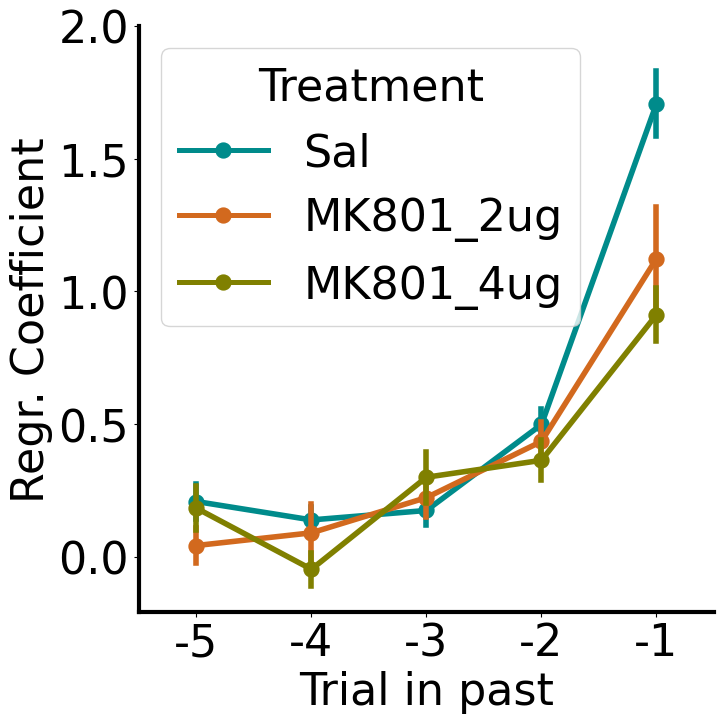

In [74]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.pointplot(x="Trial", y="value", hue="Treatment", data=m_all_pcoeffs,
              palette=["darkcyan", "chocolate", "olive"], errwidth=3, errorbar="se")
for line in ax.lines:
    line.set_linewidth(4)
ax.set_xlabel("Trial in past")
ax.set_ylabel("Regr. Coefficient")
ax.set_yticks(np.arange(0,2.01,0.5))
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)
sns.despine()

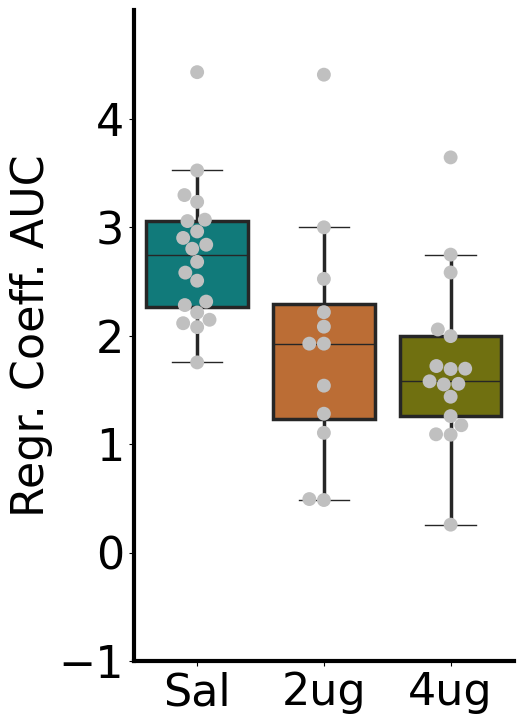

In [ ]:
#Plotting of sum of regressor coefficients in both groups
all_paucs = m_all_pcoeffs.groupby(by=["Treatment", "Trial", "variable"]).mean().reset_index()
all_paucs = all_paucs.groupby(by=["Treatment", "variable"]).sum().reset_index()
all_paucs["Treatment"] = all_paucs["Treatment"].astype(cat_size_order)
all_paucs = all_paucs.sort_values(by="Treatment")

# Plotting
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(x="Treatment", y="value", data=all_paucs, palette=[
            "darkcyan", "chocolate", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="Treatment", y="value", data=all_paucs,
              palette=["silver", "silver", "silver"], s=10)
ax.set_ylabel("Regr. Coeff. AUC")
ax.set_xlabel("")
ax.set_yticks(np.arange(-1,5,1))
ax.set_ylim(-1,5)
ax.set_xticklabels(["Sal", "2ug", "4ug"])
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
sns.despine()